# Isolated Kazakh Sign Language Recognition — KRSL-20, ADAT encoder

Classifies isolated signs from the KRSL-20 dataset (5 signers) by adapting the
encoder half of ADAT — a transformer architecture originally built for continuous
sign-to-text *translation* — into a standalone *classifier*. Test accuracy: **85.64%** (82.70% validation, trained 100 epochs, best
weights restored from epoch 99 — see Cell 9).

This notebook runs on Kaggle against a Kaggle-hosted dataset; it's published here
as a record of the approach and results, not as a clone-and-run repo.
**[Run it live on Kaggle →](https://www.kaggle.com/code/rakhatdos/isolated-kazakh-sign-language-recognition-using-th)**

## Attribution
The encoder architecture (`encoder.py`, `layers.py`, fetched in Cell 1) is not my
code — it's pulled at runtime from the official ADAT implementation:

> Shahin, N. & Ismail, L. (2026). ADAT: Novel Time-Series-Aware Adaptive Transformer
> Architecture for Sign Language Translation. *Scientific Reports*.
> https://doi.org/10.1038/s41598-026-36293-9
> Repo: https://github.com/INDUCE-Lab/ADAT-Adaptive-Transformer-for-Sign-Language-Translation
> (GPL-3.0 — see repo's LICENSE file; its README text says CC BY 4.0 but that's
> inconsistent with the actual license file, so GPL-3.0 is treated as authoritative here)

Everything from Cell 2 onward — the KRSL-20 data pipeline, the vocabulary-mapping
fix, wiring the encoder into a classification head, the training loop, and the
evaluation — is my own adaptation.


## Cell 1 — Setup

In [30]:
import os
os.makedirs('/kaggle/working/ADAT', exist_ok=True)
!wget -q https://raw.githubusercontent.com/INDUCE-Lab/ADAT-Adaptive-Transformer-for-Sign-Language-Translation/main/encoder.py -O /kaggle/working/ADAT/encoder.py
!wget -q https://raw.githubusercontent.com/INDUCE-Lab/ADAT-Adaptive-Transformer-for-Sign-Language-Translation/main/decoder.py -O /kaggle/working/ADAT/decoder.py  # fetched for completeness; unused below — this is classification (encoder-only), not translation
!wget -q https://raw.githubusercontent.com/INDUCE-Lab/ADAT-Adaptive-Transformer-for-Sign-Language-Translation/main/layers.py  -O /kaggle/working/ADAT/layers.py
!touch /kaggle/working/ADAT/__init__.py
import sys
sys.path.insert(0, '/kaggle/working/ADAT')
import tensorflow as tf
import numpy as np
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Inspect dataset

In [8]:
import os
print("Kaggle datasets:")
for d in os.listdir('/kaggle/input'):
    print(" ", d)
    for f in os.listdir(f'/kaggle/input/{d}'):
        print("   ", f)
print(os.listdir('/kaggle/input/datasets/rakhatdos/krsl-adat-data'))

Kaggle datasets:
  datasets
    rakhatdos
['video_data.npy', 'gloss_indices.npy', 'text_indices.npy']


## Cell 3 — Fix vocabulary mappings

In [20]:
import numpy as np

BASE = "/kaggle/input/datasets/rakhatdos/krsl-adat-data"
gloss_indices = np.load(f"{BASE}/gloss_indices.npy")

GLOSS_INV = {i: k for i, k in enumerate(sorted([
    "_gde","_gde_q","_kak","_kak_q","_kakoi","_kakoi_q",
    "_kogda","_kogda_q","_kotoriy","_kotoriy_q","_kto","_kto_q",
    "_kuda","_kuda_q","_skolko","_skolko_q","_what","_what_q",
    "_zachem","_zachem_q"
]))}

GLOSS_TO_ENGLISH = {
    "_gde":"where","_gde_q":"where question","_kak":"how","_kak_q":"how question",
    "_kakoi":"which","_kakoi_q":"which question","_kogda":"when","_kogda_q":"when question",
    "_kotoriy":"which one","_kotoriy_q":"which one question","_kto":"who","_kto_q":"who question",
    "_kuda":"where to","_kuda_q":"where to question","_skolko":"how many",
    "_skolko_q":"how many question","_what":"what","_what_q":"what question",
    "_zachem":"why","_zachem_q":"why question",
}

TEXT_VOCAB     = {k: i for i, k in enumerate(sorted(set(GLOSS_TO_ENGLISH.values())))}
TEXT_VOCAB_INV = {v: k for k, v in TEXT_VOCAB.items()}

print("GLOSS_INV:", GLOSS_INV)
print("TEXT_VOCAB:", TEXT_VOCAB)

text_indices_fixed = np.zeros_like(gloss_indices)
for i in range(gloss_indices.shape[0]):
    for j in range(gloss_indices.shape[1]):
        gloss_name = GLOSS_INV[gloss_indices[i, j]]
        text_indices_fixed[i, j] = TEXT_VOCAB[GLOSS_TO_ENGLISH[gloss_name]]

print("\nSample verification (first 5 rows):")
for i in range(5):
    gi = gloss_indices[i, 0]
    ti = text_indices_fixed[i, 0]
    print(f"  gloss_idx={gi} ({GLOSS_INV[gi]}) -> text_idx={ti} ({TEXT_VOCAB_INV[ti]})")

np.save("/kaggle/working/text_indices_fixed.npy", text_indices_fixed)
print("\nSaved: /kaggle/working/text_indices_fixed.npy")
print("\nGloss distribution:", np.bincount(gloss_indices[:, 0]))
print("Text  distribution:", np.bincount(text_indices_fixed[:, 0]))

GLOSS_INV: {0: '_gde', 1: '_gde_q', 2: '_kak', 3: '_kak_q', 4: '_kakoi', 5: '_kakoi_q', 6: '_kogda', 7: '_kogda_q', 8: '_kotoriy', 9: '_kotoriy_q', 10: '_kto', 11: '_kto_q', 12: '_kuda', 13: '_kuda_q', 14: '_skolko', 15: '_skolko_q', 16: '_what', 17: '_what_q', 18: '_zachem', 19: '_zachem_q'}
TEXT_VOCAB: {'how': 0, 'how many': 1, 'how many question': 2, 'how question': 3, 'what': 4, 'what question': 5, 'when': 6, 'when question': 7, 'where': 8, 'where question': 9, 'where to': 10, 'where to question': 11, 'which': 12, 'which one': 13, 'which one question': 14, 'which question': 15, 'who': 16, 'who question': 17, 'why': 18, 'why question': 19}

Sample verification (first 5 rows):
  gloss_idx=0 (_gde) -> text_idx=8 (where)
  gloss_idx=0 (_gde) -> text_idx=8 (where)
  gloss_idx=0 (_gde) -> text_idx=8 (where)
  gloss_idx=0 (_gde) -> text_idx=8 (where)
  gloss_idx=0 (_gde) -> text_idx=8 (where)

Saved: /kaggle/working/text_indices_fixed.npy

Gloss distribution: [260 260 254 258 262 260 260 

## Cell 4 — Inspection


In [10]:
# Not reproducing the full third-party source here (see Attribution above) —
# just confirming what we're importing and its shape.
!grep -nE "^(class |def |import |from )" /kaggle/working/ADAT/encoder.py
!wc -l /kaggle/working/ADAT/encoder.py

12:import tensorflow as tf
13:from layers import LogSparseSelfAttention
16:class ADATEncoder(tf.keras.layers.Layer):
121:def build_adat_encoder(num_layers, embed_dim, num_heads, ff_dim, dropout_rate):
136 /kaggle/working/ADAT/encoder.py


ROOT exists: True
WORK_DIR exists: True
✓ Saved → /kaggle/working/sign_pairs_comparison.png


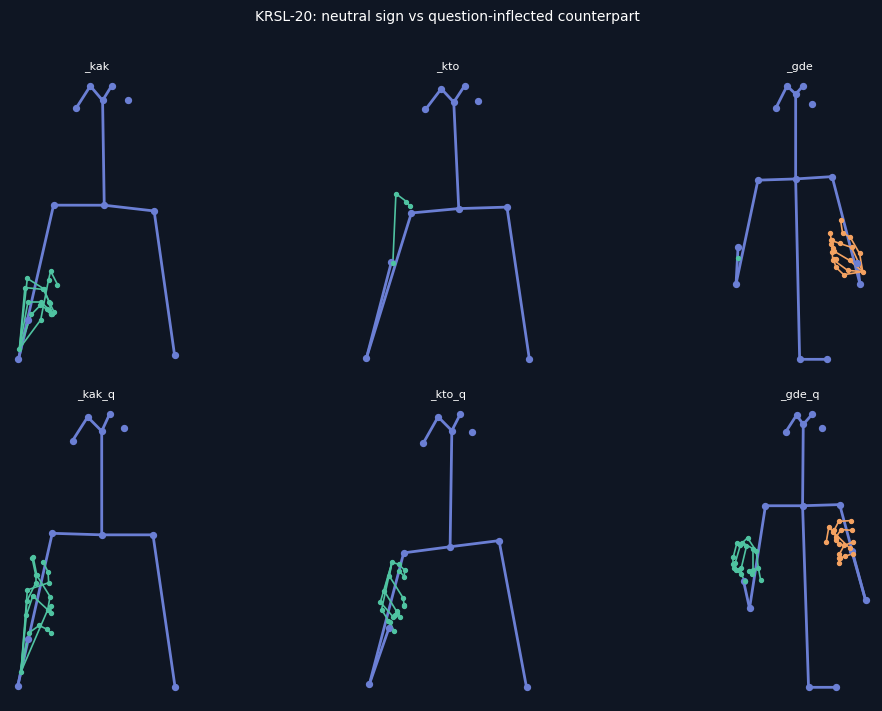

In [29]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Setup for Kaggle Notebook ─────────────────────────────
WORK_DIR = Path('/kaggle/working')
ROOT = Path('/kaggle/input/datasets/rakhatdos/v2-keypoints-5signers-isolated-signs/V2_keypoints_5signers_isolated_signs')

# Debug check
print(f'ROOT exists: {ROOT.exists()}')
print(f'WORK_DIR exists: {WORK_DIR.exists()}')

# ── Edges ────────────────────────────────────────────────
BODY_EDGES = [
    (1,0),(1,2),(1,5),(2,3),(3,4),
    (5,6),(6,7),(1,8),(8,9),(10,11),
    (8,12),(13,14),(0,15),(15,17),(0,16)
]

HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20)
]

# ── Parse JSON ───────────────────────────────────────────
def parse(path):
    with open(path) as f:
        p = json.load(f)['people'][0]

    def kp(r):
        a = np.array(r).reshape(-1, 3)
        return a[:, 0], a[:, 1], a[:, 2]

    return (
        kp(p['pose_keypoints_2d']),
        kp(p['hand_left_keypoints_2d']),
        kp(p['hand_right_keypoints_2d'])
    )

# ── Draw skeleton ────────────────────────────────────────
def draw(ax, path, title):
    (bx, by, bc), (lx, ly, lc), (rx, ry, rc) = parse(path)

    ax.set_facecolor('#0F1623')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    ax.set_title(title, color='white', fontsize=8, pad=3)

    # Body
    for a, b in BODY_EDGES:
        if bc[a] > 0.1 and bc[b] > 0.1:
            ax.plot([bx[a], bx[b]], [by[a], by[b]],
                    '-', color='#6B7FD4', lw=2)
    ax.scatter(bx[bc > 0.1], by[bc > 0.1],
               c='#6B7FD4', s=18, zorder=3)

    # Left hand
    for a, b in HAND_EDGES:
        if lc[a] > 0.05 and lc[b] > 0.05:
            ax.plot([lx[a], lx[b]], [ly[a], ly[b]],
                    '-', color='#F4A261', lw=1.2)
    ax.scatter(lx[lc > 0.05], ly[lc > 0.05],
               c='#F4A261', s=8, zorder=3)

    # Right hand
    for a, b in HAND_EDGES:
        if rc[a] > 0.05 and rc[b] > 0.05:
            ax.plot([rx[a], rx[b]], [ry[a], ry[b]],
                    '-', color='#4FC3A1', lw=1.2)
    ax.scatter(rx[rc > 0.05], ry[rc > 0.05],
               c='#4FC3A1', s=8, zorder=3)

# ── Data pairs ───────────────────────────────────────────
PAIRS = [
    ('_kak', '_kak_q'),
    ('_kto', '_kto_q'),
    ('_gde', '_gde_q'),
]

# ── Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.patch.set_facecolor('#0F1623')

fig.suptitle(
    'KRSL-20: neutral sign vs question-inflected counterpart',
    color='white', fontsize=10, y=1.01
)

for col, (neutral, question) in enumerate(PAIRS):
    for row, sign in enumerate([neutral, question]):
        folder = ROOT / sign

        signer = sorted(folder.iterdir())[0]
        jsons = sorted((signer / 'jsons').glob('*_keypoints.json'))

        frame = jsons[min(15, len(jsons) - 1)]

        draw(axes[row][col], str(frame), title=sign)

# Labels
axes[0][0].set_ylabel('Neutral', color='#F4A261', fontsize=9)
axes[1][0].set_ylabel('Question (?)', color='#4FC3A1', fontsize=9)

plt.tight_layout()

# ── Save ────────────────────────────────────────────────
output_path = WORK_DIR / 'sign_pairs_comparison.png'

plt.savefig(
    output_path,
    dpi=200,
    facecolor='#0F1623',
    bbox_inches='tight'
)

print(f'✓ Saved → {output_path}')
plt.show()

## Cell 5 — Write model_builder.py

In [11]:
%%writefile /kaggle/working/ADAT/model_builder.py
import tensorflow as tf
from encoder import build_adat_encoder

def create_adat(config):
    encoder_inputs = tf.keras.Input(
        shape=(config.max_video_length, config.feature_dim),
        dtype='float32', name='encoder_inputs'
    )
    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(config.embed_dim, activation='relu')
    )(encoder_inputs)

    adat_encoder = build_adat_encoder(
        num_layers=config.encoder_layers,
        embed_dim=config.embed_dim,
        num_heads=config.num_heads,
        ff_dim=config.hidden_units,
        dropout_rate=getattr(config, 'dropout_rate', 0.1),
    )
    encoder_outputs = adat_encoder(x)

    pooled = tf.keras.layers.GlobalAveragePooling1D()(encoder_outputs)
    pooled = tf.keras.layers.Dropout(config.dropout_rate)(pooled)

    gloss_output = tf.keras.layers.Dense(
        config.gloss_vocab_size, activation='softmax',
        dtype=tf.float32, name='gloss_output'
    )(pooled)

    return tf.keras.Model(encoder_inputs, gloss_output, name='adat')

Overwriting /kaggle/working/ADAT/model_builder.py


## Cell 6 — Write config.yaml

In [12]:
%%writefile /kaggle/working/ADAT/config.yaml
batch_size: 32
max_video_length: 100
max_gloss_length: 10
max_text_length: 10
gloss_vocab_size: 20
text_vocab_size: 20
feature_dim: 137
embed_dim: 128
encoder_layers: 3
num_heads: 8
hidden_units: 256
dropout_rate: 0.3
learning_rate: 1.0e-4
epochs: 100

Overwriting /kaggle/working/ADAT/config.yaml


## Cell 7 — Train (stratified 70/15/15 split + normalisation + class weights)

In [13]:
import os, sys, types, yaml, json
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
 
os.environ['TF_XLA_FLAGS']              = '--tf_xla_auto_jit=0'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
sys.path.insert(0, '/kaggle/working/ADAT')

from encoder import build_adat_encoder

# ── Load config from file — single source of truth ─────────────────────────
with open('/kaggle/working/ADAT/config.yaml') as f:
    config = types.SimpleNamespace(**yaml.safe_load(f))

MAX_FRAMES     = config.max_video_length
FEATURE_DIM    = config.feature_dim
EMBED_DIM      = config.embed_dim
NUM_CLASSES    = config.gloss_vocab_size
ENCODER_LAYERS = config.encoder_layers
NUM_HEADS      = config.num_heads
FF_DIM         = config.hidden_units
DROPOUT        = config.dropout_rate
LR             = config.learning_rate
BATCH          = config.batch_size
EPOCHS         = config.epochs
SEED           = 42

print("Config loaded:")
for k, v in vars(config).items():
    print(f"  {k}: {v}")

# ── Vocab ──────────────────────────────────────────────────────────────────
GLOSS_INV = {i: k for i, k in enumerate(sorted([
    '_gde','_gde_q','_kak','_kak_q','_kakoi','_kakoi_q',
    '_kogda','_kogda_q','_kotoriy','_kotoriy_q','_kto','_kto_q',
    '_kuda','_kuda_q','_skolko','_skolko_q','_what','_what_q',
    '_zachem','_zachem_q'
]))}
GLOSS_TO_ENGLISH = {
    '_gde':'where',        '_gde_q':'where question',
    '_kak':'how',          '_kak_q':'how question',
    '_kakoi':'which',      '_kakoi_q':'which question',
    '_kogda':'when',       '_kogda_q':'when question',
    '_kotoriy':'which one','_kotoriy_q':'which one question',
    '_kto':'who',          '_kto_q':'who question',
    '_kuda':'where to',    '_kuda_q':'where to question',
    '_skolko':'how many',  '_skolko_q':'how many question',
    '_what':'what',        '_what_q':'what question',
    '_zachem':'why',       '_zachem_q':'why question',
}
TEXT_VOCAB_INV = {i: k for i, k in enumerate(sorted(set(GLOSS_TO_ENGLISH.values())))}
TEXT_VOCAB     = {v: k for k, v in TEXT_VOCAB_INV.items()}
GLOSS_TO_TEXT  = {i: TEXT_VOCAB[GLOSS_TO_ENGLISH[GLOSS_INV[i]]] for i in range(20)}

# ── Load data ──────────────────────────────────────────────────────────────
BASE   = '/kaggle/input/datasets/rakhatdos/krsl-adat-data'
video  = np.load(f'{BASE}/video_data.npy')
gloss  = np.load(f'{BASE}/gloss_indices.npy')
labels = gloss[:, 0]
idx    = np.arange(len(video))

# ── Stratified 70 / 15 / 15 split ─────────────────────────────────────────
train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, random_state=SEED, stratify=labels
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=labels[temp_idx]
)

np.save('/kaggle/working/train_idx.npy', train_idx)
np.save('/kaggle/working/val_idx.npy',   val_idx)
np.save('/kaggle/working/test_idx.npy',  test_idx)

print(f'\nTrain: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}')
print(f'Train class dist: {np.bincount(labels[train_idx])}')
print(f'Val   class dist: {np.bincount(labels[val_idx])}')
print(f'Test  class dist: {np.bincount(labels[test_idx])}')

# ── Prepare arrays ─────────────────────────────────────────────────────────
v_train = video[train_idx, :MAX_FRAMES, :].astype('float32')
g_train = gloss[train_idx, 0].astype('int32')
v_val   = video[val_idx,   :MAX_FRAMES, :].astype('float32')
g_val   = gloss[val_idx,   0].astype('int32')

mean = v_train.mean(axis=(0, 1), keepdims=True)
std  = v_train.std(axis=(0, 1),  keepdims=True) + 1e-6
np.save('/kaggle/working/train_mean.npy', mean)
np.save('/kaggle/working/train_std.npy',  std)

v_train = (v_train - mean) / std
v_val   = (v_val   - mean) / std

counts = np.bincount(g_train, minlength=NUM_CLASSES)
class_weight = {
    i: len(g_train) / (NUM_CLASSES * c)
    for i, c in enumerate(counts) if c > 0
}
print(f'\nClass weights min={min(class_weight.values()):.3f} max={max(class_weight.values()):.3f}')

# ── Model ──────────────────────────────────────────────────────────────────
def build_model():
    inp = tf.keras.Input(shape=(MAX_FRAMES, FEATURE_DIM), name='encoder_inputs')
    x   = tf.keras.layers.TimeDistributed(
              tf.keras.layers.Dense(EMBED_DIM, activation='relu'))(inp)
    for _ in range(ENCODER_LAYERS):
        x = build_adat_encoder(
                num_layers=1, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                ff_dim=FF_DIM, dropout_rate=DROPOUT)(x)
    x   = tf.keras.layers.GlobalAveragePooling1D()(x)
    x   = tf.keras.layers.Dropout(DROPOUT)(x)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax',
                                name='gloss_output')(x)
    return tf.keras.Model(inp, out, name='adat')

model = build_model()
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False,
)

# ── Datasets ───────────────────────────────────────────────────────────────
def make_ds(v, g, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((v, g))
    if shuffle:
        ds = ds.shuffle(len(v), seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(v_train, g_train, shuffle=True)
val_ds   = make_ds(v_val,   g_val)

print(f'\nGPUs: {tf.config.list_physical_devices("GPU")}')

# ── Train ──────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            '/kaggle/working/best_model.weights.h5',
            save_best_only=True, monitor='val_loss',
            save_weights_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-6, verbose=1),
    ]
)
print('Training complete!')

with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals]
               for k, vals in history.history.items()}, f)
print("History saved.")

Config loaded:
  batch_size: 32
  max_video_length: 100
  max_gloss_length: 10
  max_text_length: 10
  gloss_vocab_size: 20
  text_vocab_size: 20
  feature_dim: 137
  embed_dim: 128
  encoder_layers: 3
  num_heads: 8
  hidden_units: 256
  dropout_rate: 0.3
  learning_rate: 0.0001
  epochs: 100

Train: 3669  Val: 786  Test: 787
Train class dist: [182 182 178 181 183 182 182 183 224 167 180 181 182 181 181 182 182 182
 182 192]
Val   class dist: [39 39 38 38 39 39 39 39 48 36 39 39 39 39 39 39 39 39 39 41]
Test  class dist: [39 39 38 39 40 39 39 40 48 35 38 38 39 39 39 39 39 39 39 42]

Class weights min=0.819 max=1.099


I0000 00:00:1777988168.743081      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "adat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_inputs (InputLayer)     │ (None, 100, 137)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 128)       │        17,664 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adat_encoder (ADATEncoder)      │ (None, 100, 128)       │        53,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adat_encoder_1 (ADATEncoder)    │ (None, 100, 128)       │        53,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adat_encoder_2 (ADATEncoder)    │ (None, 100, 128)       │        53,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gloss_output (Dense)            │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,911 (710.59 KB)

 Trainable params: 181,911 (710.59 KB)

 Non-trainable params: 0 (0.00 B)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/100


I0000 00:00:1777988182.958590     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


[Full 100-epoch Keras progress-bar log condensed for readability — every value below
 is pulled directly from the original run, just sub-sampled to every 10th epoch plus
 the first, the best (early-stopping restore point), and the last. See the Training
 curve plot further down for the complete per-epoch trend.]

Epoch | train_acc | train_loss | val_acc | val_loss
----------------------------------------------------
    1 |    0.0629 |     3.2085 |  0.1883 |   2.6480
    5 |    0.3446 |     1.9691 |  0.4059 |   1.7907
   10 |    0.4998 |     1.4176 |  0.5560 |   1.2945
   20 |    0.6259 |     0.9753 |  0.6781 |   0.8644
   30 |    0.7074 |     0.7273 |  0.6832 |   0.7480
   40 |    0.7482 |     0.6087 |  0.7226 |   0.6974
   50 |    0.8032 |     0.5291 |  0.7430 |   0.6096
   60 |    0.8123 |     0.4813 |  0.7799 |   0.5414
   70 |    0.8498 |     0.3904 |  0.8041 |   0.5066
   80 |    0.8758 |     0.3462 |  0.8079 |   0.4479
   90 |    0.8896 |     0.3065 |  0.8295 |   0.4341
   99 | 

## Cell 8 — Validation evaluation

In [14]:
from collections import Counter

# Load best weights back into model already in memory
model.load_weights('/kaggle/working/best_model.weights.h5')

# v_val and g_val already in memory from training cell
preds          = model.predict(v_val, batch_size=64, verbose=1)
gloss_pred_idx = preds.argmax(axis=-1)
gloss_true_idx = g_val

text_pred_idx = np.array([GLOSS_TO_TEXT[int(g)] for g in gloss_pred_idx])
text_true_idx = np.array([GLOSS_TO_TEXT[int(g)] for g in gloss_true_idx])

# Sample table
print(f"\n{'Sample':>6}  {'True Gloss':<20} {'Pred Gloss':<20} "
      f"{'True Text':<20} {'Pred Text':<20} Match")
print('-' * 100)
for i in range(20):
    tg = GLOSS_INV[int(gloss_true_idx[i])]
    pg = GLOSS_INV[int(gloss_pred_idx[i])]
    tt = TEXT_VOCAB_INV[int(text_true_idx[i])]
    pt = TEXT_VOCAB_INV[int(text_pred_idx[i])]
    print(f"{i:>6}  {tg:<20} {pg:<20} {tt:<20} {pt:<20} "
          f"{'✅' if tg == pg else '❌'}")

gloss_acc = np.mean(gloss_pred_idx == gloss_true_idx)
print(f'\nVal Gloss accuracy : {gloss_acc*100:.2f}%')
print(f'Val Text  accuracy : {gloss_acc*100:.2f}%  (lookup)')

print('\n=== VAL PER-CLASS ACCURACY ===')
for gi in range(20):
    mask = gloss_true_idx == gi
    if mask.sum() == 0: continue
    acc = np.mean(gloss_pred_idx[mask] == gi)
    bar = '█' * int(acc * 20)
    print(f"  {GLOSS_INV[gi]:<20}  {acc*100:5.1f}%  {bar}")

print('\n=== CONFUSION PER CLASS ===')
for gi in range(20):
    mask = gloss_true_idx == gi
    if mask.sum() == 0: continue
    top3    = Counter(gloss_pred_idx[mask].tolist()).most_common(3)
    correct = sum(c for p, c in top3 if p == gi)
    top_str = ', '.join([f'{GLOSS_INV[p]}({c})' for p, c in top3])
    print(f"  {GLOSS_INV[gi]:<20} -> {top_str}   [{correct}/{mask.sum()}]")

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 303ms/step

Sample  True Gloss           Pred Gloss           True Text            Pred Text            Match
----------------------------------------------------------------------------------------------------
     0  _kuda                _kuda_q              where to             where to question    ❌
     1  _skolko              _skolko              how many             how many             ✅
     2  _kak                 _kak_q               how                  how question         ❌
     3  _kuda                _kuda                where to             where to             ✅
     4  _zachem              _zachem_q            why                  why question         ❌
     5  _zachem_q            _zachem_q            why question         why question         ✅
     6  _kogda               _kogda               when                 when                 ✅
     7  _kotoriy_q           _kotoriy_q           which one question   which one question   ✅
     8 

## Cell 9 — Test evaluation (run only once at the very end)

Test set was never used during training or model selection.

In [15]:
from collections import Counter
import numpy as np

# Load saved normalisation stats from training
mean = np.load('/kaggle/working/train_mean.npy')
std  = np.load('/kaggle/working/train_std.npy')

BASE      = '/kaggle/input/datasets/rakhatdos/krsl-adat-data'
video     = np.load(f'{BASE}/video_data.npy')
gloss     = np.load(f'{BASE}/gloss_indices.npy')
test_idx  = np.load('/kaggle/working/test_idx.npy')
MAX_FRAMES = 100

GLOSS_INV = {i: k for i, k in enumerate(sorted([
    '_gde','_gde_q','_kak','_kak_q','_kakoi','_kakoi_q',
    '_kogda','_kogda_q','_kotoriy','_kotoriy_q','_kto','_kto_q',
    '_kuda','_kuda_q','_skolko','_skolko_q','_what','_what_q',
    '_zachem','_zachem_q'
]))}

# Apply same normalisation as training
v_test          = video[test_idx, :MAX_FRAMES, :].astype('float32')
v_test          = (v_test - mean) / std
gloss_test_true = gloss[test_idx, 0]

model.load_weights('/kaggle/working/best_model.weights.h5')
test_preds      = model.predict(v_test, batch_size=64, verbose=1)
gloss_test_pred = test_preds.argmax(axis=-1)

test_acc = (gloss_test_pred == gloss_test_true).mean()

# Recompute val accuracy directly — no dependency on Cell 8 variables
val_idx_reload = np.load('/kaggle/working/val_idx.npy')
mean = np.load('/kaggle/working/train_mean.npy')
std  = np.load('/kaggle/working/train_std.npy')
v_val_reload   = video[val_idx_reload, :MAX_FRAMES, :].astype('float32')
v_val_reload   = (v_val_reload - mean) / std
g_val_reload   = gloss[val_idx_reload, 0]
val_preds      = model.predict(v_val_reload, batch_size=64, verbose=0)
val_acc        = (val_preds.argmax(axis=-1) == g_val_reload).mean() * 100
print(f"\n{'='*50}")
print(f"TEST  accuracy : {test_acc*100:.2f}%")
print(f"VAL   accuracy : {val_acc:.2f}%")
print(f"Gap            : {abs(val_acc - test_acc*100):.2f}%")
print(f"{'='*50}")

print('\n=== TEST PER-CLASS ACCURACY ===')
for gi in range(20):
    mask = gloss_test_true == gi
    if mask.sum() == 0: continue
    acc = (gloss_test_pred[mask] == gi).mean()
    bar = '█' * int(acc * 20)
    print(f"  {GLOSS_INV[gi]:<20}  {acc*100:5.1f}%  {bar}")

print('\n=== TEST CONFUSION PER CLASS ===')
for gi in range(20):
    mask = gloss_test_true == gi
    if mask.sum() == 0: continue
    top3    = Counter(gloss_test_pred[mask].tolist()).most_common(3)
    correct = sum(c for p, c in top3 if p == gi)
    top_str = ', '.join([f'{GLOSS_INV[p]}({c})' for p, c in top3])
    print(f"  {GLOSS_INV[gi]:<20} -> {top_str}   [{correct}/{mask.sum()}]")

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step

TEST  accuracy : 85.64%
VAL   accuracy : 82.70%
Gap            : 2.94%

=== TEST PER-CLASS ACCURACY ===
  _gde                   84.6%  ████████████████
  _gde_q                 76.9%  ███████████████
  _kak                   71.1%  ██████████████
  _kak_q                 92.3%  ██████████████████
  _kakoi                 92.5%  ██████████████████
  _kakoi_q               82.1%  ████████████████
  _kogda                 89.7%  █████████████████
  _kogda_q               92.5%  ██████████████████
  _kotoriy               85.4%  █████████████████
  _kotoriy_q             88.6%  █████████████████
  _kto                   84.2%  ████████████████
  _kto_q                 78.9%  ███████████████
  _kuda                  82.1%  ████████████████
  _kuda_q                94.9%  ██████████████████
  _skolko                94.9%  ██████████████████
  _skolko_q              87.2%  █████████████████
  _what                  79.5%  ███████████████
  _what_q   

## Training curve

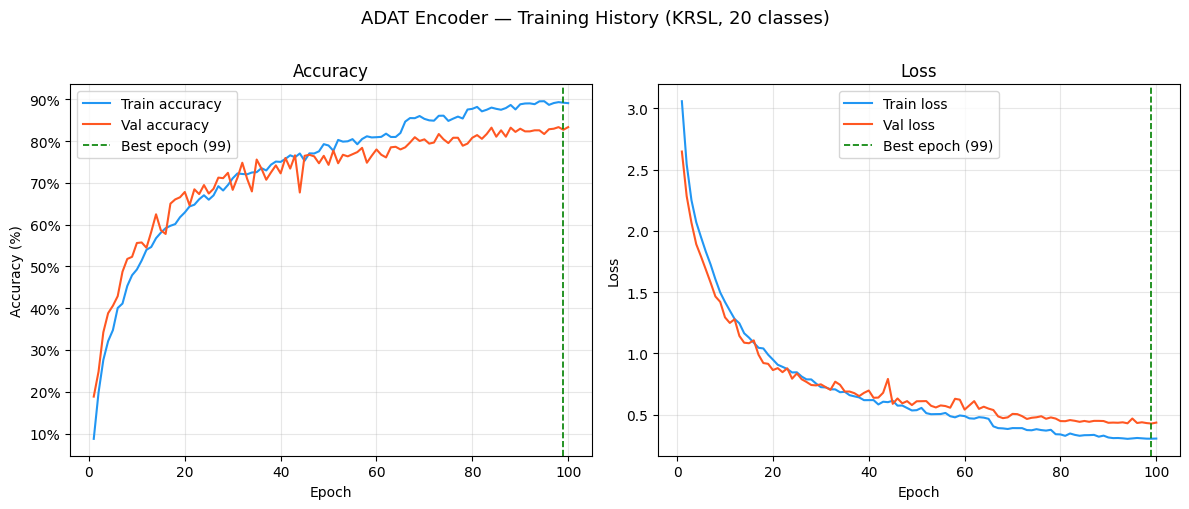

Best epoch: 99


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json

with open('/kaggle/working/training_history.json') as f:
    hist = json.load(f)

train_acc  = hist['accuracy']
val_acc    = hist['val_accuracy']
train_loss = hist['loss']
val_loss   = hist['val_loss']
epochs     = list(range(1, len(train_acc) + 1))
best_epoch = int(val_loss.index(min(val_loss))) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ADAT Encoder — Training History (KRSL, 20 classes)", fontsize=13, y=1.01)

ax1.plot(epochs, [v*100 for v in train_acc], label="Train accuracy", color="#2196F3", linewidth=1.5)
ax1.plot(epochs, [v*100 for v in val_acc],   label="Val accuracy",   color="#FF5722", linewidth=1.5)
ax1.axvline(best_epoch, color="green", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

ax2.plot(epochs, train_loss, label="Train loss", color="#2196F3", linewidth=1.5)
ax2.plot(epochs, val_loss,   label="Val loss",   color="#FF5722", linewidth=1.5)
ax2.axvline(best_epoch, color="green", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Best epoch: {best_epoch}")

## Per class accuracy 

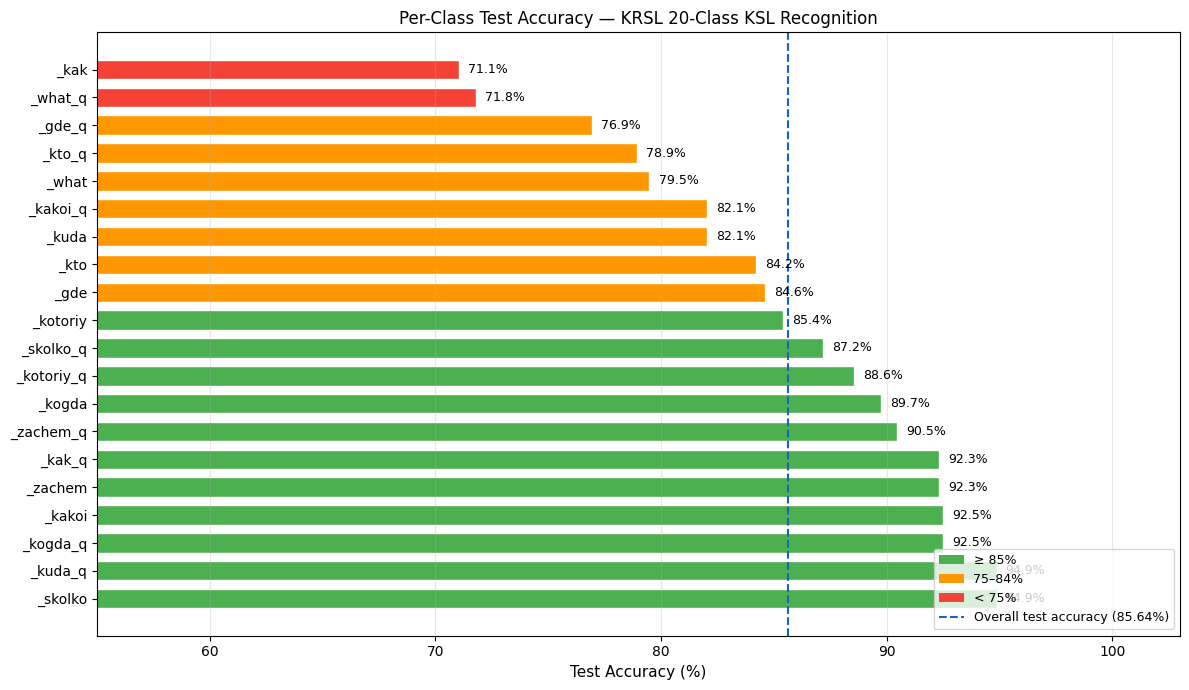

Overall test accuracy: 85.64%
Saved: fig_perclass_accuracy.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Compute per-class accuracy from actual predictions
# gloss_test_pred and gloss_test_true must be in memory from Cell 9
GLOSS_INV = {i: k for i, k in enumerate(sorted([
    '_gde','_gde_q','_kak','_kak_q','_kakoi','_kakoi_q',
    '_kogda','_kogda_q','_kotoriy','_kotoriy_q','_kto','_kto_q',
    '_kuda','_kuda_q','_skolko','_skolko_q','_what','_what_q',
    '_zachem','_zachem_q'
]))}

classes  = [GLOSS_INV[i] for i in range(20)]
test_accs = []
for gi in range(20):
    mask = gloss_test_true == gi
    acc  = (gloss_test_pred[mask] == gi).mean() * 100 if mask.sum() > 0 else 0.0
    test_accs.append(acc)

overall_acc = (gloss_test_pred == gloss_test_true).mean() * 100

# Sort descending
sorted_pairs = sorted(zip(test_accs, classes), reverse=True)
accs_sorted, names_sorted = zip(*sorted_pairs)

colors = ["#4CAF50" if a >= 85 else "#FF9800" if a >= 75 else "#F44336"
          for a in accs_sorted]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(names_sorted, accs_sorted, color=colors,
               edgecolor='white', height=0.7)

for bar, val in zip(bars, accs_sorted):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9)

ax.axvline(overall_acc, color='#1565C0', linestyle='--', linewidth=1.5)
ax.set_xlabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Test Accuracy — KRSL 20-Class KSL Recognition', fontsize=12)
ax.set_xlim(55, 103)
ax.grid(True, axis='x', alpha=0.3)

legend_elements = [
    Patch(facecolor='#4CAF50', label='≥ 85%'),
    Patch(facecolor='#FF9800', label='75–84%'),
    Patch(facecolor='#F44336', label='< 75%'),
    plt.Line2D([0], [0], color='#1565C0', linestyle='--',
               label=f'Overall test accuracy ({overall_acc:.2f}%)')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('/kaggle/working/fig_perclass_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Overall test accuracy: {overall_acc:.2f}%")
print("Saved: fig_perclass_accuracy.png")

## Confusion matrix 

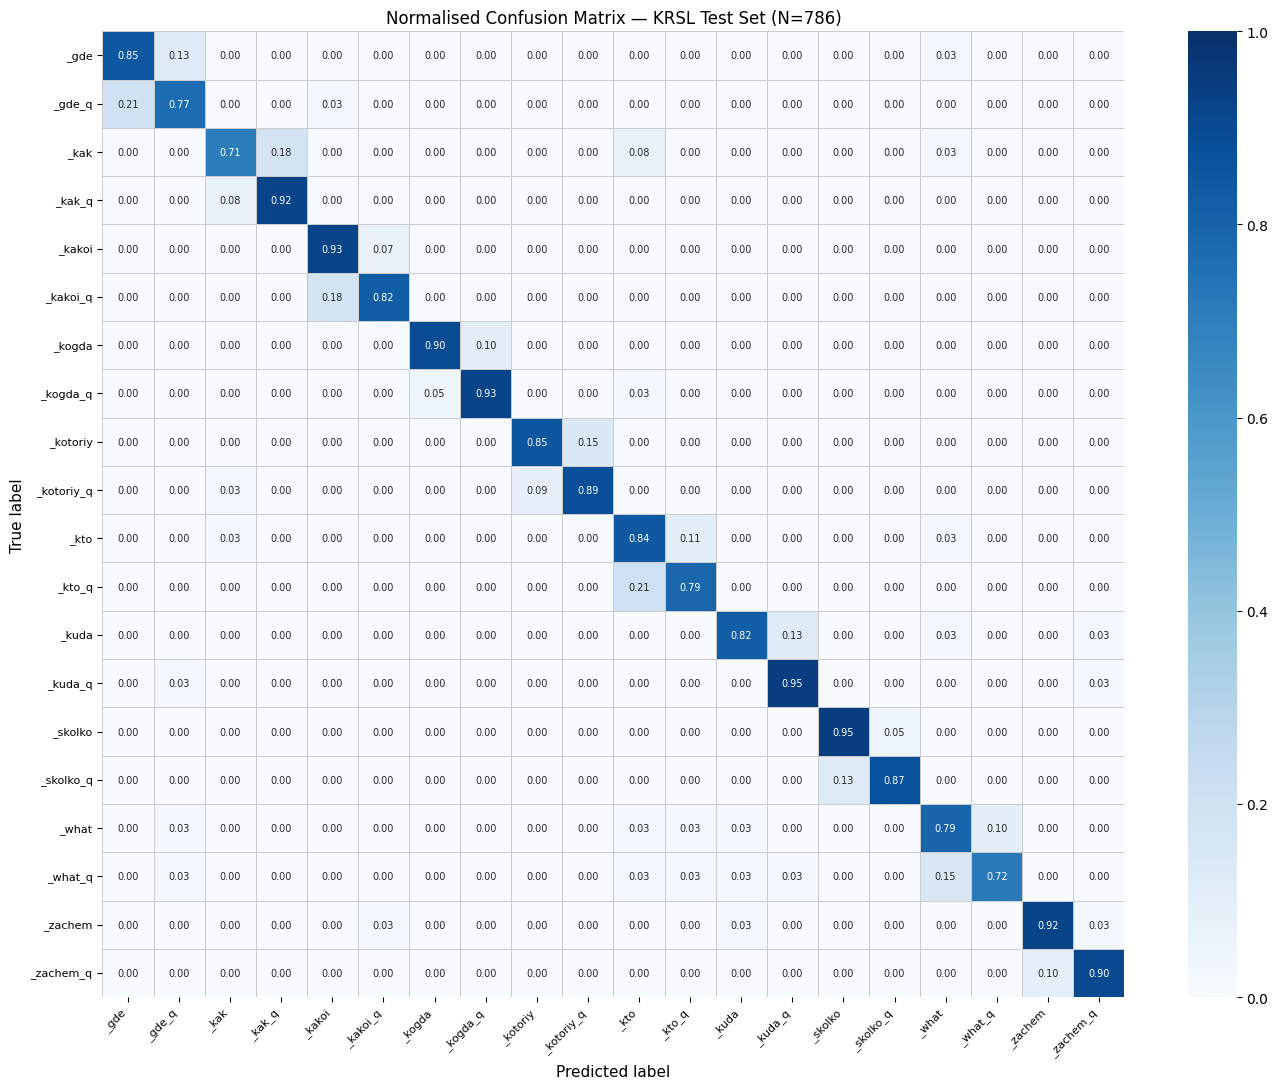

Saved: fig_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Uses gloss_test_pred and gloss_test_true from your test eval cell
GLOSS_INV = {i: k for i, k in enumerate(sorted([
    '_gde','_gde_q','_kak','_kak_q','_kakoi','_kakoi_q',
    '_kogda','_kogda_q','_kotoriy','_kotoriy_q','_kto','_kto_q',
    '_kuda','_kuda_q','_skolko','_skolko_q','_what','_what_q',
    '_zachem','_zachem_q'
]))}

labels = [GLOSS_INV[i] for i in range(20)]
cm = confusion_matrix(gloss_test_true, gloss_test_pred, normalize='true')

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm, annot=True, fmt='.2f',
    xticklabels=labels, yticklabels=labels,
    cmap='Blues', linewidths=0.4, linecolor='#CCCCCC',
    vmin=0, vmax=1, ax=ax,
    annot_kws={"size": 7}
)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title('Normalised Confusion Matrix — KRSL Test Set (N=786)', fontsize=12)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_confusion_matrix.png")

## ROC-curve

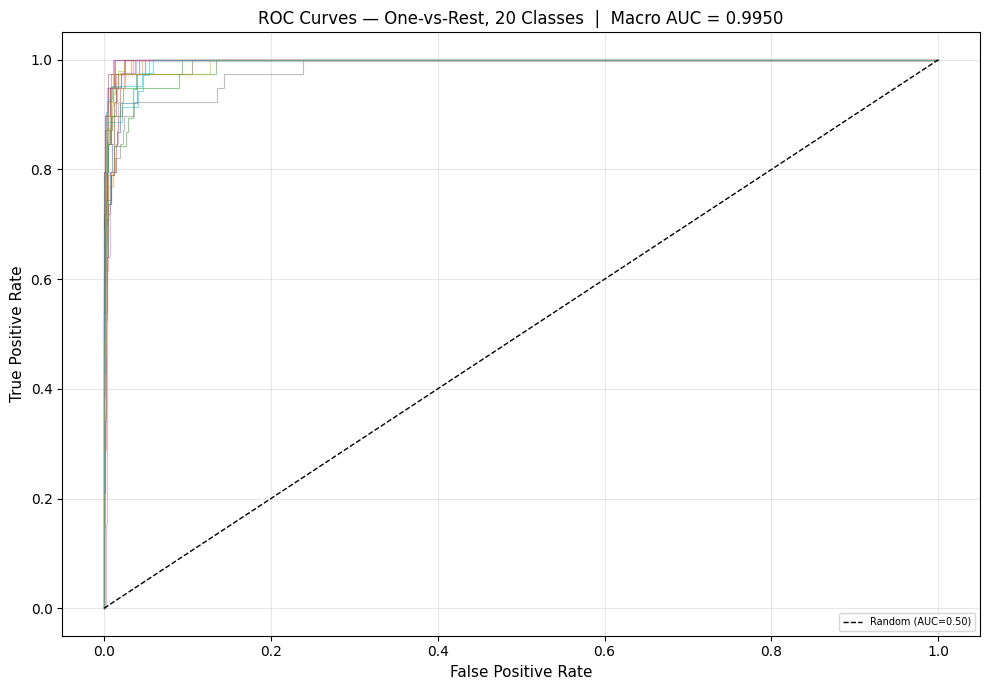

Macro AUC: 0.9950
Saved: fig_roc_curves.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# test_preds = raw softmax probabilities from model.predict() in your test cell
y_bin = label_binarize(gloss_test_true, classes=list(range(20)))

fig, ax = plt.subplots(figsize=(10, 7))

macro_auc_vals = []
for i in range(20):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_preds[:, i])
    roc_auc = auc(fpr, tpr)
    macro_auc_vals.append(roc_auc)
    ax.plot(fpr, tpr, linewidth=0.8, alpha=0.5,
            label=f'{GLOSS_INV[i]} (AUC={roc_auc:.2f})')

macro_avg = np.mean(macro_auc_vals)

# Diagonal reference line
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'ROC Curves — One-vs-Rest, 20 Classes  |  Macro AUC = {macro_avg:.4f}', fontsize=12)
ax.legend(fontsize=7, loc='lower right', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Macro AUC: {macro_avg:.4f}")
print("Saved: fig_roc_curves.png")